<a href="https://colab.research.google.com/github/Seetharamanpp/Facebook-Live-Sellers-Dataset-Analysis/blob/main/Facebook_Live_Sellers_Dataset_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Facebook Live Sellers Dataset Analysis

Objective

The goal of this project is to analyze Facebook live seller data and understand user engagement patterns based on reactions,
comments, and shares. We will also apply clustering techniques to group posts based on engagement levels.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the Dataset

In [ ]:
df = pd.read_csv("/Facebook_Marketplace_data.csv")
df.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


Basic Information about the Dataset

In [ ]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   int64  
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(10), object(2)
memory

Data Cleaning

We will clean column names and convert numerical columns to proper format.

In [ ]:
df.columns = df.columns.str.strip()
df.columns

Index(['status_id', 'status_type', 'status_published', 'num_reactions',
       'num_comments', 'num_shares', 'num_likes', 'num_loves', 'num_wows',
       'num_hahas', 'num_sads', 'num_angrys', 'Column1', 'Column2', 'Column3',
       'Column4'],
      dtype='object')

In [ ]:
cols = ['num_reactions', 'num_comments', 'num_shares',
'num_likes', 'num_loves', 'num_wows',
'num_hahas', 'num_sads', 'num_angrys']
for col in cols:
  df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna(subset=cols)

Summary Statistics

In [ ]:
df.describe()

,status_id,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,0.0,0.0,0.0,0.0
mean,3525.500000,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191,NaN,NaN,NaN,NaN
std,2035.304031,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812,NaN,NaN,NaN,NaN
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,1763.250000,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,3525.500000,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,5287.750000,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
max,7050.000000,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000,NaN,NaN,NaN,NaN


Data Visualization

We explore the distribution and relationships between variables.

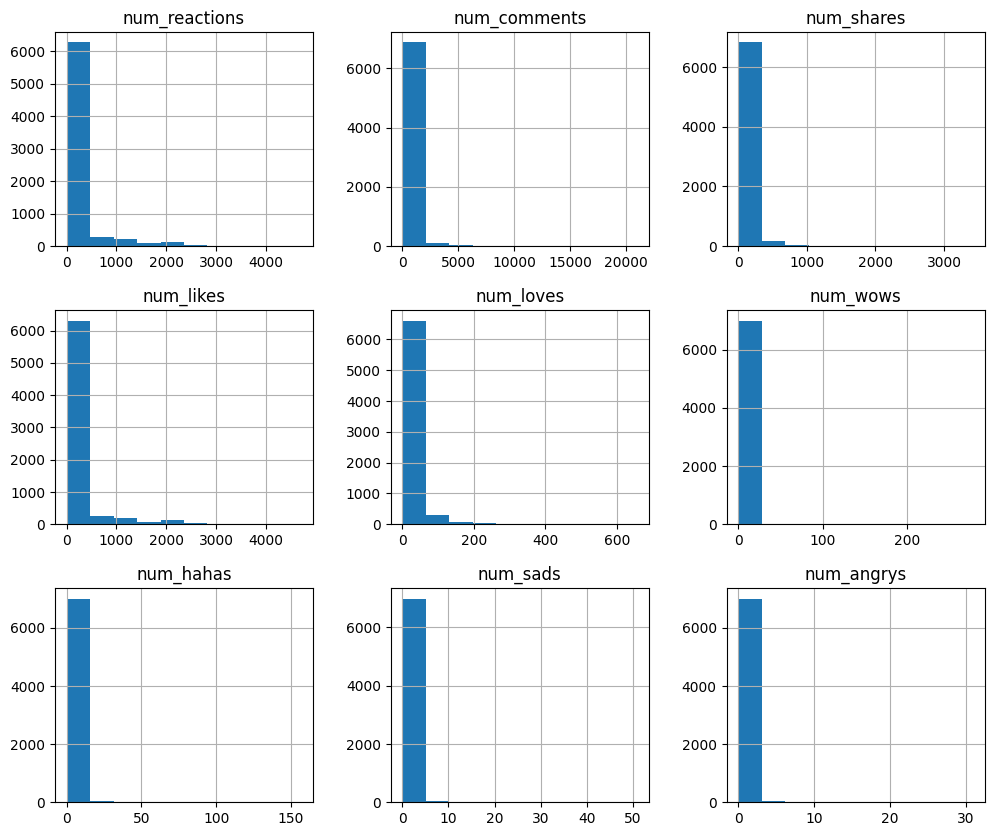

In [ ]:
df[cols].hist(figsize=(12,10))
plt.show()

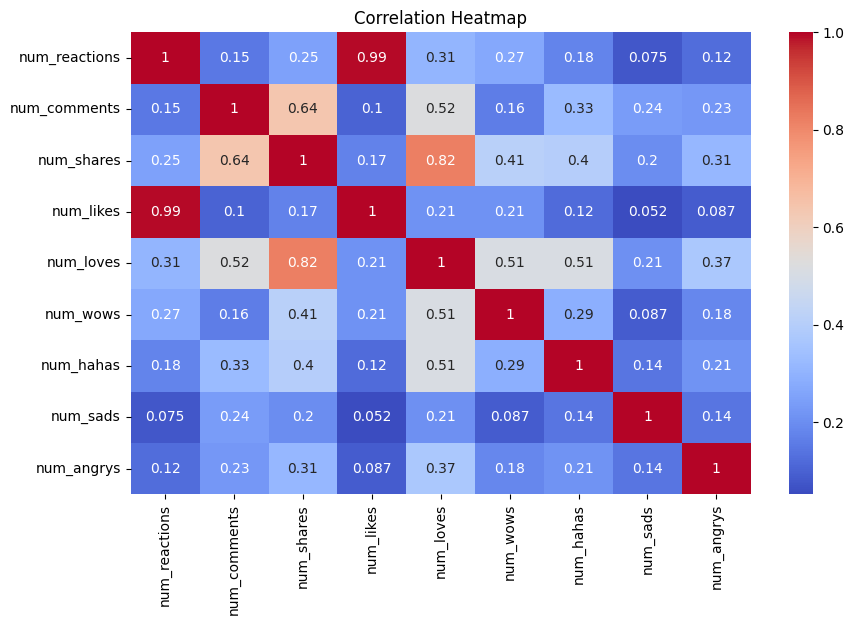

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

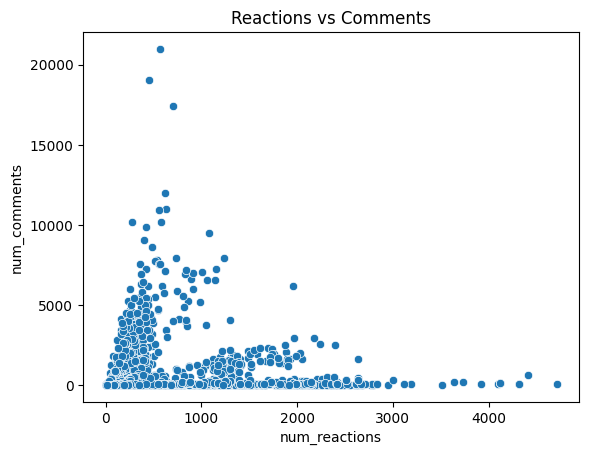

In [ ]:
sns.scatterplot(x='num_reactions', y='num_comments', data=df)
plt.title("Reactions vs Comments")
plt.show()

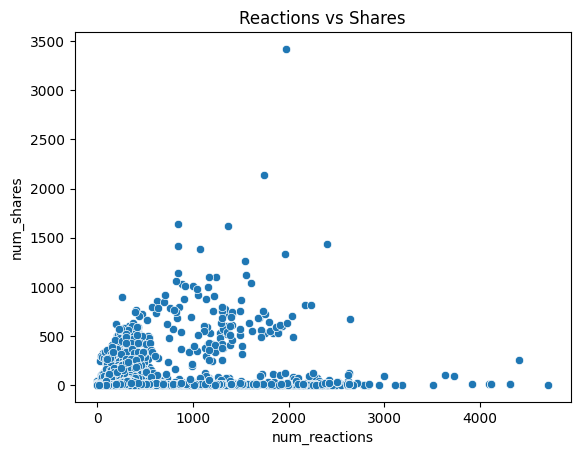

In [ ]:
sns.scatterplot(x='num_reactions', y='num_shares', data=df)
plt.title("Reactions vs Shares")
plt.show()

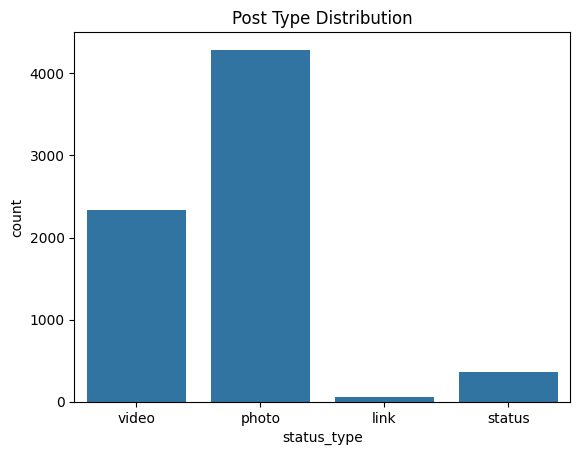

In [ ]:
sns.countplot(x='status_type', data=df)
plt.title("Post Type Distribution")
plt.show()

Clustering Analysis

We use KMeans clustering to group posts based on engagement.

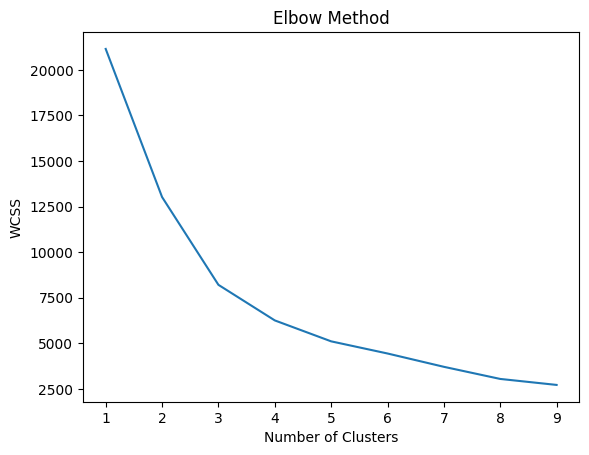

In [ ]:
X = df[['num_reactions', 'num_comments', 'num_shares']]
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 10):
  kmeans = KMeans(n_clusters=i, random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

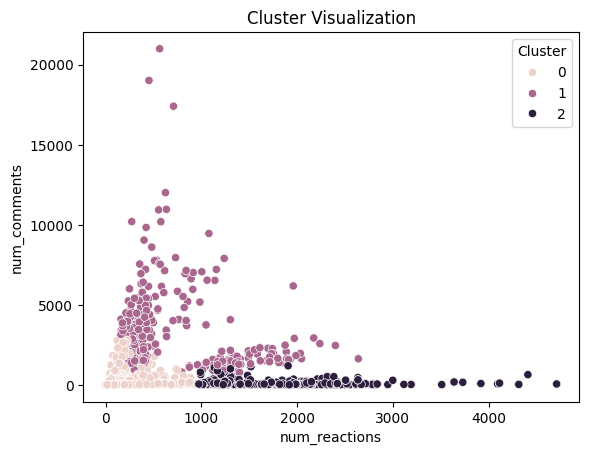

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)
sns.scatterplot(x='num_reactions', y='num_comments', hue='Cluster', data=df)
plt.title("Cluster Visualization")
plt.show()

In [ ]:
df.groupby('Cluster')[['num_reactions','num_comments','num_shares']].mean()

,num_reactions,num_comments,num_shares
Cluster,,,
0,113.026250,86.440742,19.004873
1,695.360656,3282.780328,507.373770
2,1804.616188,79.702350,16.973890


Conclusion


*   Posts with higher reactions tend to receive more comments and shares.


*   Strong positive correlation exists between engagement metrics.



*   Clustering reveals different levels of engagement

  1.   Cluster 0: Low engagement
  2.   Cluster 1: Medium engagement
  3.    Cluster 2: High engagement
  

*   This analysis helps understand what type of posts perform better.














Q1: Time vs Reactions

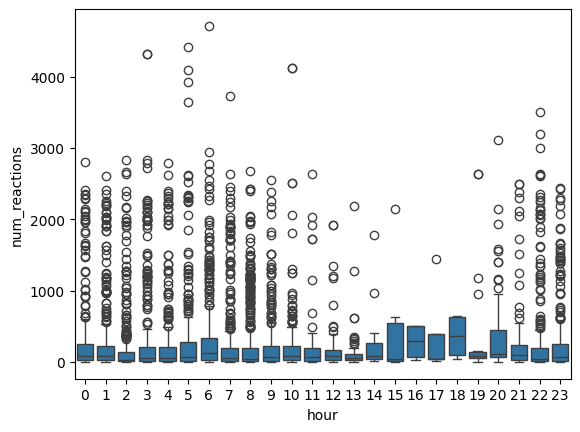

In [ ]:
df['status_published'] = pd.to_datetime(df['status_published'])
df['hour'] = df['status_published'].dt.hour
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='hour', y='num_reactions', data=df)
plt.show()

2.Is there a correlation between the number of reactions (num_reactions) and other engagement metrics such as comments
(num_comments) and shares (num_shares)? If so, what is the strength and direction of this correlation?

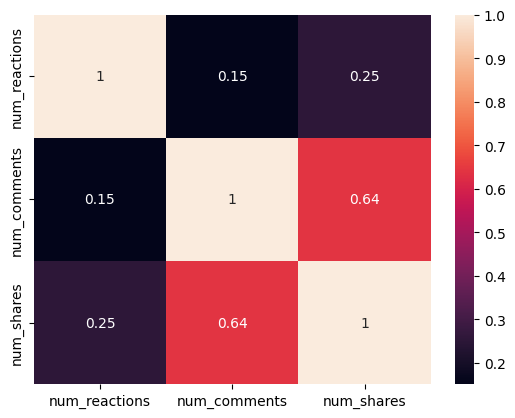

In [ ]:
sns.heatmap(df[['num_reactions','num_comments','num_shares']].corr(), annot=True)
plt.show()

3.Use the columns status_type, num_reactions, num_comments, num_shares, num_likes, num_loves, num_wows, num_hahas,
num_sads, and num_angrys to train a K-Means clustering model on the Facebook Live Sellers dataset.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

features = df[['num_reactions','num_comments','num_shares',
               'num_likes','num_loves','num_wows',
               'num_hahas','num_sads','num_angrys']]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(scaled_data)

4.Use the elbow method to find the optimum number of clusters.

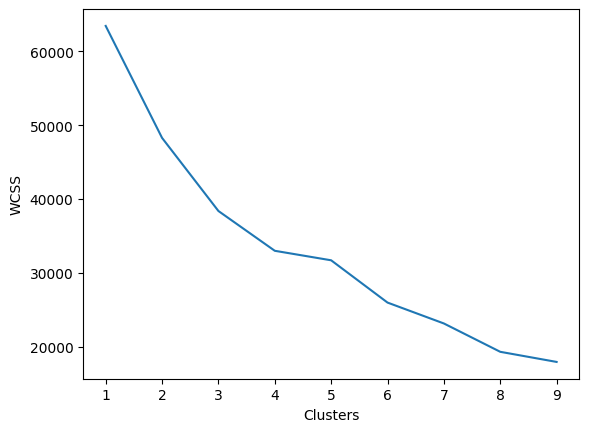

In [ ]:
wcss = []
for i in range(1,10):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()

5.What is the count of different types of posts in the dataset?

In [ ]:
df['status_type'].value_counts()

,count
status_type,
photo,4288
video,2334
status,365
link,63


6.What is the average value of num_reaction, num_comments, num_shares for each post type?

In [ ]:
df.groupby('status_type')[['num_reactions','num_comments','num_shares']].mean()

,num_reactions,num_comments,num_shares
status_type,,,
link,370.142857,5.698413,4.396825
photo,181.290345,15.993470,2.553871
status,438.783562,36.238356,2.558904
video,283.409597,642.478149,115.679949
